In [ ]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

from lib import *

path = "../data/Fashion-MNIST"
X_train, y_train, X_test, y_test = load_MINST_dataset(path)
X_train, X_test = flatten_images(X_train, X_test)

In [2]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.pipeline import Pipeline
import numpy as np

def tune_rbf_pipeline(X_train, y_train, X_test, y_test, hp_list, dim_reduction=None):
    results = {}
    
    for hp in hp_list:
        if dim_reduction is None:
            pipeline = Pipeline([
                ('scaler', TimedTask(StandardScaler())),
                ('svc', TimedTask(SVC(kernel='rbf', C=hp[0], gamma=hp[1],  random_state=42)))
            ], verbose=True)
            print(f"Training RBF SVC with hp={hp}...")
            results[hp] = evaluate_pipeline(pipeline, X_train, y_train, X_test, y_test)
        else:
            pipeline = Pipeline([
                ('scaler', TimedTask(StandardScaler())),
                ('reduce_dim', TimedTask(dim_reduction)),
                ('svc', TimedTask(SVC(kernel='rbf', C=hp[0], gamma=hp[1],  random_state=42)))
            ], verbose=True)
            print(f"Training RBF SVC with hp={hp}...")
            results[hp] = evaluate_pipeline(pipeline, X_train, y_train, X_test, y_test)
        
    return results

def plot_rbf_bar_chart(result, title):
    tuples = list(result.keys())
    x_labels = [f"C={c}\nγ={g}" for c, g in tuples]

    train_acc = [result[k]['train_acc'] for k in tuples]
    test_acc = [result[k]['test_acc'] for k in tuples]

    x = np.arange(len(x_labels)) 
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.bar(x - width/2, train_acc, width, label='Train Accuracy', color='#4C72B0')
    ax.bar(x + width/2, test_acc, width, label='Test Accuracy', color='#55A868')

    ax.set_ylabel('Accuracy')
    ax.set_title(f'Hyperparameter Tuning: {title}')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.legend(loc='lower right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    min_acc = min(min(train_acc), min(test_acc))
    ax.set_ylim([max(0, min_acc - 0.02), 1.0])

    plt.tight_layout()
    plt.show()

    table = pd.DataFrame(result).T
    table.index = pd.MultiIndex.from_tuples(table.index, names=['C', 'Gamma'])
    table = table[['train_time', 'train_acc', 'test_acc', 'step_times']].copy()
    table.columns = ['Training Time','Training Accuracy', 'Test Accuracy', 'Step Times']

    return result, table

Training RBF SVC with hp=(1, 0.001)...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   2.3s
[Pipeline] ............... (step 2 of 2) Processing svc, total=10.5min
Training RBF SVC with hp=(10, 0.001)...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   1.6s
[Pipeline] ............... (step 2 of 2) Processing svc, total= 5.0min
Training RBF SVC with hp=(50, 0.001)...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   2.1s
[Pipeline] ............... (step 2 of 2) Processing svc, total= 9.1min
Training RBF SVC with hp=(100, 0.001)...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   1.6s
[Pipeline] ............... (step 2 of 2) Processing svc, total= 9.0min


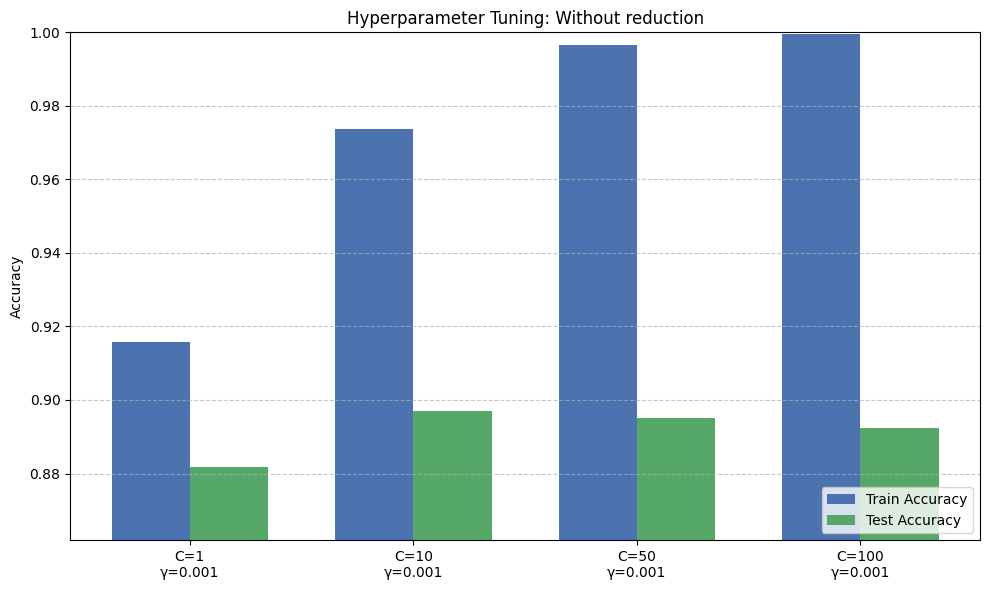

({(1, 0.001): {'train_time': 630.1311193000001,
   'train_acc': 0.9157666666666666,
   'test_acc': 0.8819},
  (10, 0.001): {'train_time': 304.27926389999993,
   'train_acc': 0.9735833333333334,
   'test_acc': 0.897},
  (50, 0.001): {'train_time': 549.0240517999991,
   'train_acc': 0.9964333333333333,
   'test_acc': 0.8951},
  (100, 0.001): {'train_time': 538.7026363000004,
   'train_acc': 0.9994833333333333,
   'test_acc': 0.8925}},
            Training Time  Training Accuracy  Test Accuracy
 C   Gamma                                                 
 1   0.001     630.131119           0.915767         0.8819
 10  0.001     304.279264           0.973583         0.8970
 50  0.001     549.024052           0.996433         0.8951
 100 0.001     538.702636           0.999483         0.8925)

In [3]:
fine_tuned_options = [
    (1, 0.001),
    (10, 0.001),
    (50, 0.001),
    (100, 0.001),
]
result = tune_rbf_pipeline(X_train, y_train, X_test, y_test, fine_tuned_options)
plot_rbf_bar_chart(result, "Without reduction")

Training RBF SVC with hp=(1, 0.003)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   2.5s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.4s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.6min
Training RBF SVC with hp=(10, 0.0005)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.5s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.4s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.2min
Training RBF SVC with hp=(10, 0.001)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.4s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.6s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.2min
Training RBF SVC with hp=(30, 0.001)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.3s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.0s
[Pipeline] ............... (step 3 of 3) Processing svc, to

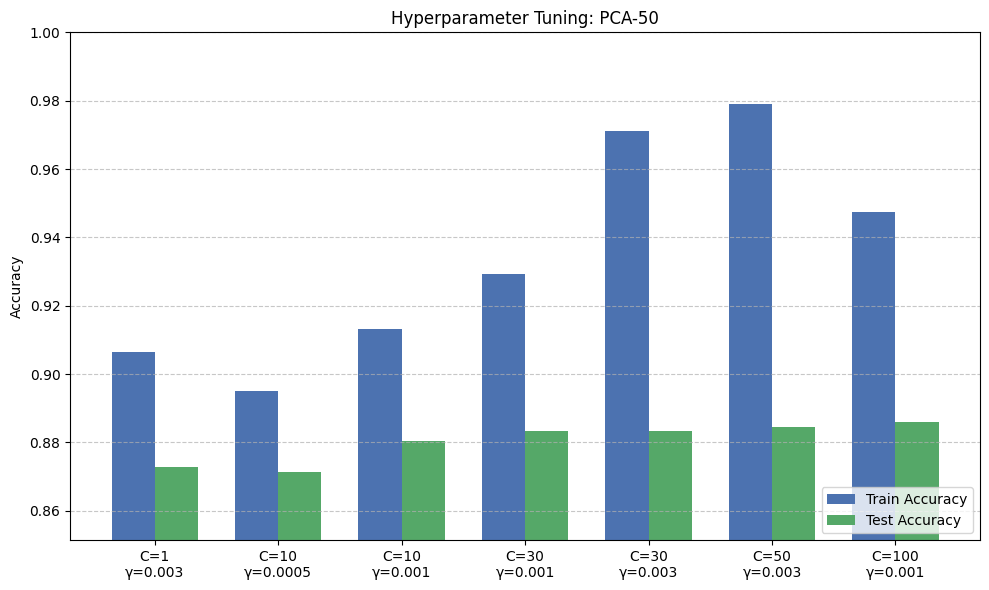

({(1, 0.003): {'train_time': 102.73510709998664,
   'train_acc': 0.9063833333333333,
   'test_acc': 0.8729},
  (10, 0.0005): {'train_time': 74.70287019998068,
   'train_acc': 0.8950166666666667,
   'test_acc': 0.8714},
  (10, 0.001): {'train_time': 73.43053029998555,
   'train_acc': 0.9131,
   'test_acc': 0.8804},
  (30, 0.001): {'train_time': 73.91524329999811,
   'train_acc': 0.9294166666666667,
   'test_acc': 0.8834},
  (30, 0.003): {'train_time': 99.22441460000118,
   'train_acc': 0.9711166666666666,
   'test_acc': 0.8832},
  (50, 0.003): {'train_time': 102.14371090001077,
   'train_acc': 0.9790333333333333,
   'test_acc': 0.8844},
  (100, 0.001): {'train_time': 86.15154510000139,
   'train_acc': 0.9474833333333333,
   'test_acc': 0.8861}},
             Training Time  Training Accuracy  Test Accuracy
 C   Gamma                                                  
 1   0.0030     102.735107           0.906383         0.8729
 10  0.0005      74.702870           0.895017         0.8714
 

In [3]:
fine_tuned_options_50 = [
    (1, 0.003),
    (10, 0.0005),
    (10, 0.001),
    (30, 0.001),
    (30, 0.003),
    (50, 0.003),
    (100, 0.001),  
]
result_50 = tune_rbf_pipeline(X_train, y_train, X_test, y_test, fine_tuned_options_50, PCA(n_components=50))
plot_rbf_bar_chart(result_50, "PCA-50")

Training RBF SVC with hp=(10, 0.0001)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   2.2s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.4s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.5min
Training RBF SVC with hp=(10, 0.0005)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.2s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   0.8s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.2min
Training RBF SVC with hp=(10, 0.001)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.2s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   0.8s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.3min
Training RBF SVC with hp=(30, 0.0002)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.1s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   0.8s
[Pipeline] ............... (step 3 of 3) Processing svc,

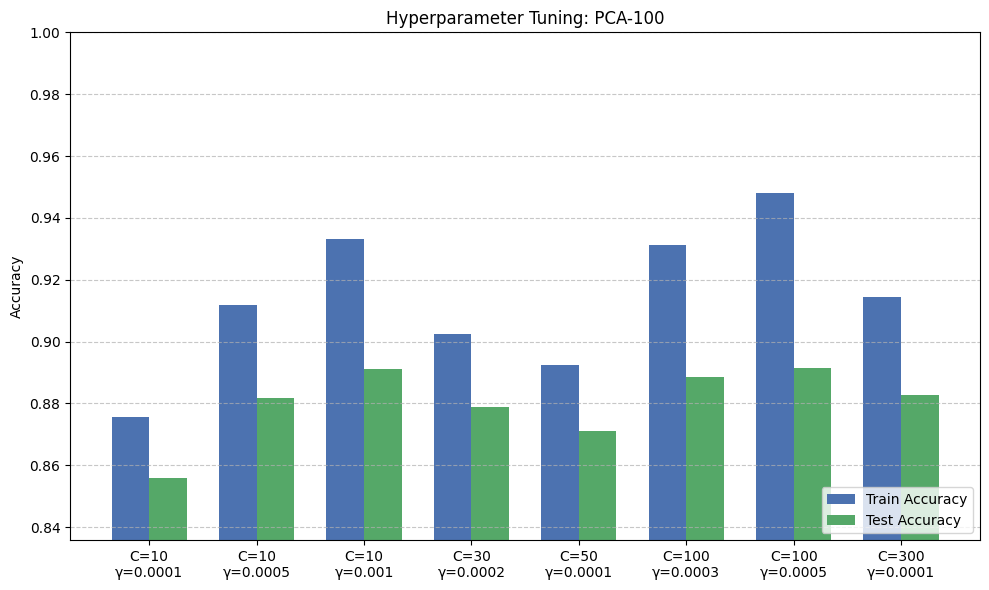

({(10, 0.0001): {'train_time': 96.09778520002146,
   'train_acc': 0.8755,
   'test_acc': 0.8558},
  (10, 0.0005): {'train_time': 76.08501950002392,
   'train_acc': 0.9118333333333334,
   'test_acc': 0.8816},
  (10, 0.001): {'train_time': 78.56543400001829,
   'train_acc': 0.93325,
   'test_acc': 0.8912},
  (30, 0.0002): {'train_time': 76.80979470000602,
   'train_acc': 0.9023166666666667,
   'test_acc': 0.8788},
  (50, 0.0001): {'train_time': 81.73135720001301,
   'train_acc': 0.8925666666666666,
   'test_acc': 0.8712},
  (100, 0.0003): {'train_time': 78.81063809999614,
   'train_acc': 0.9312166666666667,
   'test_acc': 0.8886},
  (100, 0.0005): {'train_time': 81.38724919999368,
   'train_acc': 0.94805,
   'test_acc': 0.8916},
  (300, 0.0001): {'train_time': 86.79145660001086,
   'train_acc': 0.9143,
   'test_acc': 0.8827}},
             Training Time  Training Accuracy  Test Accuracy
 C   Gamma                                                  
 10  0.0001      96.097785           0.87

In [4]:
fine_tuned_options_100 = [
    (10, 0.0001),
    (10, 0.0005),
    (10, 0.001),
    (30, 0.0002),
    (50, 0.0001),
    (100, 0.0003),
    (100, 0.0005),
    (300, 0.0001), 
]
result_100 = tune_rbf_pipeline(X_train, y_train, X_test, y_test, fine_tuned_options_100, PCA(n_components=100))
plot_rbf_bar_chart(result_100, "PCA-100")

Training RBF SVC with hp=(30, 5e-05)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.2s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.0s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.9min
Training RBF SVC with hp=(30, 1e-05)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.3s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.4s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 2.5min
Training RBF SVC with hp=(50, 1e-05)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.2s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.2s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 2.4min
Training RBF SVC with hp=(100, 0.0001)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.0s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.2s
[Pipeline] ............... (step 3 of 3) Processing svc, 

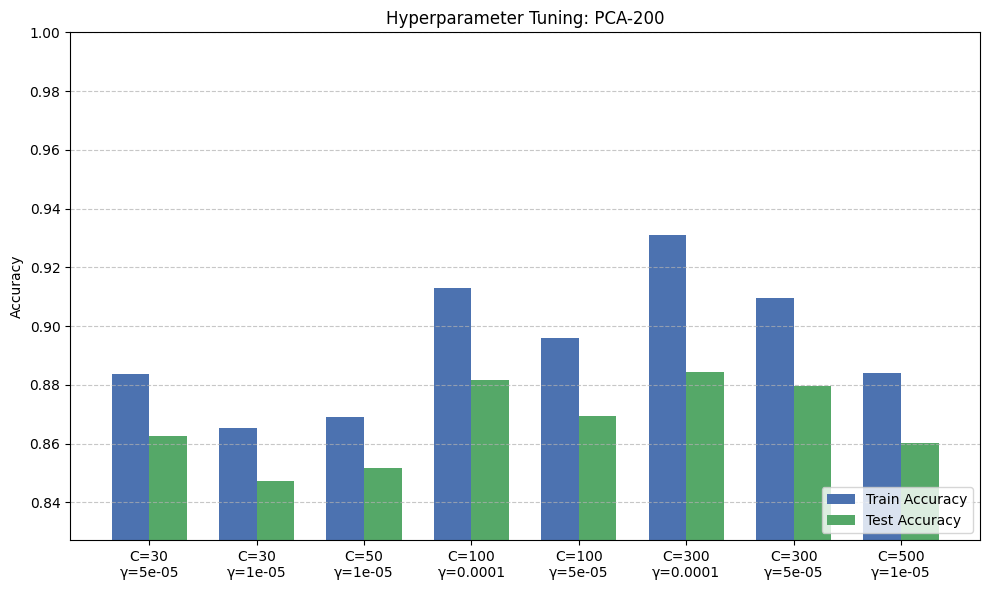

({(30, 5e-05): {'train_time': 117.9942718000093,
   'train_acc': 0.8838333333333334,
   'test_acc': 0.8625},
  (30, 1e-05): {'train_time': 152.3201381000108,
   'train_acc': 0.8652833333333333,
   'test_acc': 0.8472},
  (50, 1e-05): {'train_time': 146.1737976000004,
   'train_acc': 0.8691333333333333,
   'test_acc': 0.8518},
  (100, 0.0001): {'train_time': 115.63412060000701,
   'train_acc': 0.9131166666666667,
   'test_acc': 0.8816},
  (100, 5e-05): {'train_time': 120.3641687000054,
   'train_acc': 0.8959833333333334,
   'test_acc': 0.8693},
  (300, 0.0001): {'train_time': 126.28202949999832,
   'train_acc': 0.9309333333333333,
   'test_acc': 0.8843},
  (300, 5e-05): {'train_time': 123.08785849998822,
   'train_acc': 0.9095666666666666,
   'test_acc': 0.8797},
  (500, 1e-05): {'train_time': 127.87862540001515,
   'train_acc': 0.8839833333333333,
   'test_acc': 0.8601}},
              Training Time  Training Accuracy  Test Accuracy
 C   Gamma                                            

In [5]:
fine_tuned_options_200 = [
    (30, 0.00005),
    (30, 0.00001),
    (50, 0.00001),
    (100, 0.0001),
    (100, 0.00005),
    (300, 0.0001),
    (300, 0.00005),
    (500, 0.00001),
]
result_200 = tune_rbf_pipeline(X_train, y_train, X_test, y_test, fine_tuned_options_200, PCA(n_components=200))
plot_rbf_bar_chart(result_200, "PCA-200")

Training RBF SVC with hp=(1, 0.01)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   2.3s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=  14.6s
[Pipeline] ............... (step 3 of 3) Processing svc, total=  24.3s
Training RBF SVC with hp=(1, 0.1)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.0s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=  11.6s
[Pipeline] ............... (step 3 of 3) Processing svc, total=  27.1s
Training RBF SVC with hp=(10, 0.01)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.1s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=  12.3s
[Pipeline] ............... (step 3 of 3) Processing svc, total=  23.9s
Training RBF SVC with hp=(10, 0.1)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.0s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=  10.6s
[Pipeline] ............... (step 3 of 3) Processing svc, total=  30

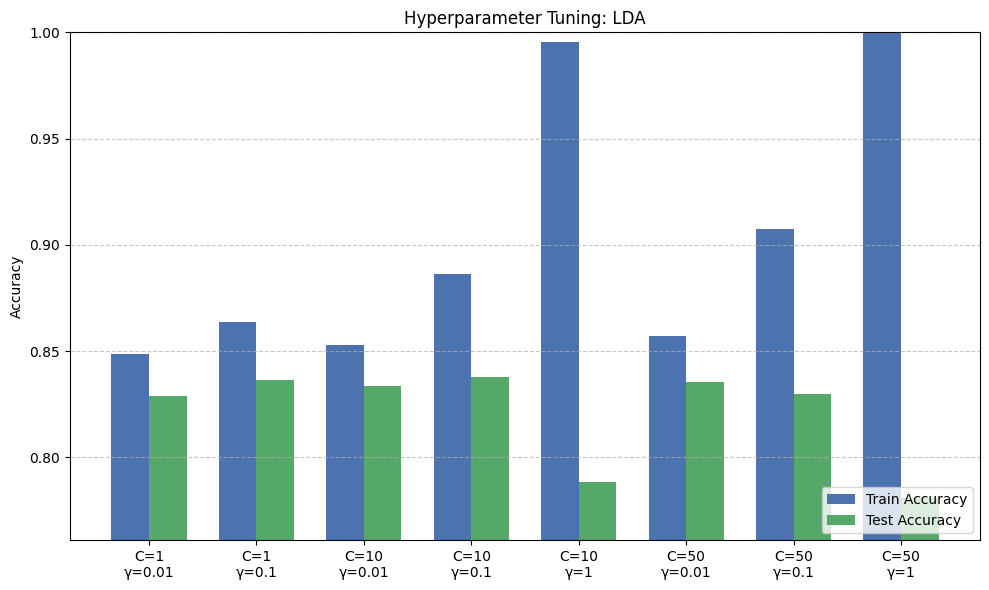

({(1, 0.01): {'train_time': 41.309337500017136,
   'train_acc': 0.8486166666666667,
   'test_acc': 0.8289},
  (1, 0.1): {'train_time': 39.7008319000015,
   'train_acc': 0.8636333333333334,
   'test_acc': 0.8362},
  (10, 0.01): {'train_time': 37.3446896999958,
   'train_acc': 0.8526833333333333,
   'test_acc': 0.8335},
  (10, 0.1): {'train_time': 42.519413500034716,
   'train_acc': 0.8860666666666667,
   'test_acc': 0.8377},
  (10, 1): {'train_time': 251.40865569998277,
   'train_acc': 0.9954,
   'test_acc': 0.7884},
  (50, 0.01): {'train_time': 40.84474530001171,
   'train_acc': 0.85695,
   'test_acc': 0.8354},
  (50, 0.1): {'train_time': 61.24763510003686,
   'train_acc': 0.9074666666666666,
   'test_acc': 0.8298},
  (50, 1): {'train_time': 251.5380804000306,
   'train_acc': 0.9996833333333334,
   'test_acc': 0.7811}},
           Training Time  Training Accuracy  Test Accuracy
 C  Gamma                                                 
 1  0.01       41.309338           0.848617       

In [6]:
fine_tuned_options_lda = [
    (1, 0.01),
    (1, 0.1),
    (10, 0.01),
    (10, 0.1),
    (10, 1),
    (50, 0.01),
    (50, 0.1),
    (50, 1),
]
result_lda = tune_rbf_pipeline(X_train, y_train, X_test, y_test, fine_tuned_options_lda, LinearDiscriminantAnalysis(n_components=9))
plot_rbf_bar_chart(result_lda, "LDA")